# Lesson 1 - Text Generation

Welcome to Lesson 1.

To access the `requirements.txt` file, go to `File` and click on `Open`.

In this lesson, we'll cover the following:

1. How to load an LLM from HuggingFace?
2. How to generate a token from the model output tensors?
3. Prefill and decode: optimizing token generation over multiple steps

I hope you enjoy this course!

### Import required packages

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import time
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

c:\Users\Cynth\.conda\envs\clipreid\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. How to load an LLM from HuggingFace?

- Load the LLM
- You'll use GPT2 throughout this course

为什么要先写 model_name？
-因为 tokenizer 和 model 必须来自同一个模型家族。
-比如你用了 GPT-2 模型，就最好用 GPT-2 对应的 tokenizer。

In [4]:
model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

- Examine the model's architecture

In [5]:
print(model)

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2SdpaAttention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)


## 2. How to generate a token from the model output tensors?

### Text Generation
- Start by tokenizing the input prompt

In [ ]:
prompt = "The quick brown fox jumped over the"
inputs = tokenizer(prompt, return_tensors="pt")   #tokenizer2个作用：1.把人类可读的文字翻译成模型可读的 token id；2.把这些 token id 翻译成文字
inputs

{'input_ids': tensor([[  464,  2068,  7586, 21831, 11687,   625,   262]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1]])}

- Pass the inputs to the model and retrieve the logits to find the most likely next token

In [7]:
with torch.no_grad():
    outputs = model(**inputs)   #**inputs 的意思 把 inputs 这个字典拆开，作为参数交给模型。

logits = outputs.logits
print(logits.shape)

torch.Size([1, 7, 50257])


In [ ]:
last_logits = logits[0, -1, :]   #取第 1 个句子的最后一个 token 位置， 看它对所有候选下一个 token 的分数。
next_token_id = last_logits.argmax()  #从所有候选 token 的分数里，选出分数最高的那个 token 的编号
next_token_id

tensor(13990)

- Decode the most likely token

In [ ]:
tokenizer.decode(next_token_id) #把这个 token id 翻译成人类可读的文字。

' fence'

- Print the 10 most likely next words

In [ ]:
top_k = torch.topk(last_logits, k=10)
#top_K 是一个包含两个属性的对象：values 和 indices。values 是这 10 个 token 的分数，indices 是这 10 个 token 的编号。
tokens = [tokenizer.decode(tk) for tk in top_k.indices]
tokens

[' fence',
 ' edge',
 ' railing',
 ' wall',
 ' table',
 ' tree',
 ' top',
 ' counter',
 ' ground',
 ' side']

- Concatenate the input and most likely tokens 把刚刚生成出来的 next_token_id 接到原来的输入后面，组成下一轮模型输入

In [12]:
next_inputs = {
    "input_ids": torch.cat(
        [inputs["input_ids"], next_token_id.reshape((1, 1))],
        dim=1
    ),
    "attention_mask": torch.cat(
        [inputs["attention_mask"], torch.tensor([[1]])],
        dim=1
    ),
}

In [13]:
print(next_inputs["input_ids"],
      next_inputs["input_ids"].shape)
print(next_inputs["attention_mask"],
      next_inputs["attention_mask"].shape)

tensor([[  464,  2068,  7586, 21831, 11687,   625,   262, 13990]]) torch.Size([1, 8])
tensor([[1, 1, 1, 1, 1, 1, 1, 1]]) torch.Size([1, 8])


## 3. Prefill and decode: optimizing token generation over multiple steps

### Text generation helper function
- The following helper function generates the next tokens given a set of input tokens
- Prefill = 第一次处理完整 prompt。
- Decode = 后面一个 token 一个 token 地生成。
- KV cache 的作用就是：第一次 prefill 的时候，把前面 token 的中间计算结果存下来；后面 decode 的时候，不要重复算历史，只算最新 token。

### 没有 KV cache:每次写一个新词，都重新读一遍整篇 prompt。

比如：

- 读 7 个 token → 写第 8 个
- 读 8 个 token → 写第 9 个
- 读 9 个 token → 写第 10 个
- 读 10 个 token → 写第 11 个

### 有 KV cache: 第一次认真读 prompt，并做笔记。 后面只读新生成的 token，同时参考旧笔记。

比如：

- prefill：读 7 个 token，保存 KV cache，写第 8 个
- decode：只读 token8 + 旧 cache，写第 9 个
- decode：只读 token9 + 旧 cache，写第 10 个
- decode：只读 token10 + 旧 cache，写第 11 个

这就是优化的核心。

### 1.不使用 KV cache 的多步生成

In [14]:
def generate_token(inputs):
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    last_logits = logits[0, -1, :]
    next_token_id = last_logits.argmax()
    return next_token_id

- Use the helper function to generate multiple tokens in a loop
- Track the time it takes to generate each token

In [15]:
generated_tokens = []
next_inputs = inputs
durations_s = []
for _ in range(10):
    t0 = time.time()
    next_token_id = generate_token(next_inputs)
    durations_s += [time.time() - t0]
    
    next_inputs = {
        "input_ids": torch.cat(
            [next_inputs["input_ids"], next_token_id.reshape((1, 1))],
            dim=1),
        "attention_mask": torch.cat(
            [next_inputs["attention_mask"], torch.tensor([[1]])],
            dim=1),
    }
    
    next_token = tokenizer.decode(next_token_id)
    generated_tokens.append(next_token)

print(f"{sum(durations_s)} s")
print(generated_tokens)

0.7758281230926514 s
[' fence', ' and', ' ran', ' to', ' the', ' other', ' side', ' of', ' the', ' fence']


- Plot token generation time
- The x-axis here is the token number
- The y-axis is the time to generate a token in millisenconds (ms)

**Note**: Your plot may vary slightly from the one shown in the video, yet it will exhibit a similar pattern.

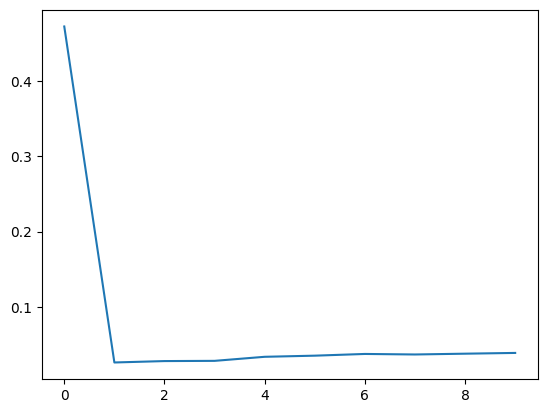

In [16]:
plt.plot(durations_s)
plt.show()

### 2. Speeding up text generation with KV-caching
KV-caching is a technique to speed up token generation by storing some of the tensors in the attention head for use in subsequent generation steps
- Modify the generate helper function to return the next token and the key/value tensors
- 上一版：每次都把完整 input_ids 重新喂给模型。
- 这一版：第一次喂完整 prompt，后面每次只喂最新生成的 1 个 token + past_key_values。

In [18]:
def generate_token_with_past(inputs):
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    last_logits = logits[0, -1, :]
    next_token_id = last_logits.argmax()
    return next_token_id, outputs.past_key_values

- Generate 10 tokens using the updated helper function

In [19]:
generated_tokens = []
next_inputs = inputs
durations_cached_s = []
for _ in range(10):
    t0 = time.time()
    next_token_id, past_key_values = \
        generate_token_with_past(next_inputs)
    durations_cached_s += [time.time() - t0]
    
    next_inputs = {
        "input_ids": next_token_id.reshape((1, 1)),
        "attention_mask": torch.cat(
            [next_inputs["attention_mask"], torch.tensor([[1]])],
            dim=1),
        "past_key_values": past_key_values,
    }
    
    next_token = tokenizer.decode(next_token_id)
    generated_tokens.append(next_token)

print(f"{sum(durations_cached_s)} s")
print(generated_tokens)

0.2521209716796875 s
[' fence', ' and', ' ran', ' to', ' the', ' other', ' side', ' of', ' the', ' fence']


- Compare the execution time for the KV-cache function with the original helper function

**Note**: Your plot may vary slightly from the one shown in the video, yet it will exhibit a similar pattern.

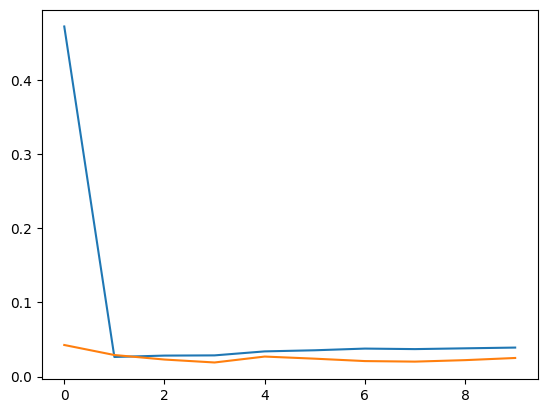

In [20]:
plt.plot(durations_s)
plt.plot(durations_cached_s)
plt.show()